In [41]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv


In [42]:
# Using Titanic Dataset with features already engineered for binary logistic regression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [43]:
X = pd.read_csv("/kaggle/input/datasets/heptapod/titanic/train_and_test2.csv")
y = X.iloc[:,-1]
X = X.iloc[:,:-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
class LogReg:
    def __init__(self,alpha=0.01,iters=1000):
        self.w = None
        self.b = None
        self.alpha = alpha
        self.iters = iters
        self.J_history = []

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))

    def compute_cost(self,X,y,y_hat):
        m,n = X.shape
        # cost = 1/m * sigma(-yilog(hi)-(1-yi)log(1-hi))
        y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15) # To avoid log(0) errors
        cost = (-1/m) * np.sum(y * np.log(y_hat) + (1-y) * np.log(1-y_hat))
        return cost

    def fit(self,X,y):
        m,n = X.shape
        self.w = np.zeros(n)
        self.b = 0
        for i in range(self.iters):
            # Find h = sigmoid
            y_hat = self.sigmoid(X@self.w + self.b)

            # Find Gradient
            dJ_dw = (1/m)*X.T@(y_hat-y)
            dJ_db = (1/m)*(np.sum(y_hat-y))

            # Update parameteras
            self.w-=self.alpha*(dJ_dw)
            self.b-=self.alpha*(dJ_db)

            if(i%10==0):
                self.J_history.append(self.compute_cost(X,y,y_hat))

    def predict(self,X):
        z = X@self.w + self.b
        probs = self.sigmoid(z)
        # Set boundary as 0.5 : Can change for safer predictions 
        return (probs>=0.5).astype(int)

In [45]:
model = LogReg(alpha=0.01,iters=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

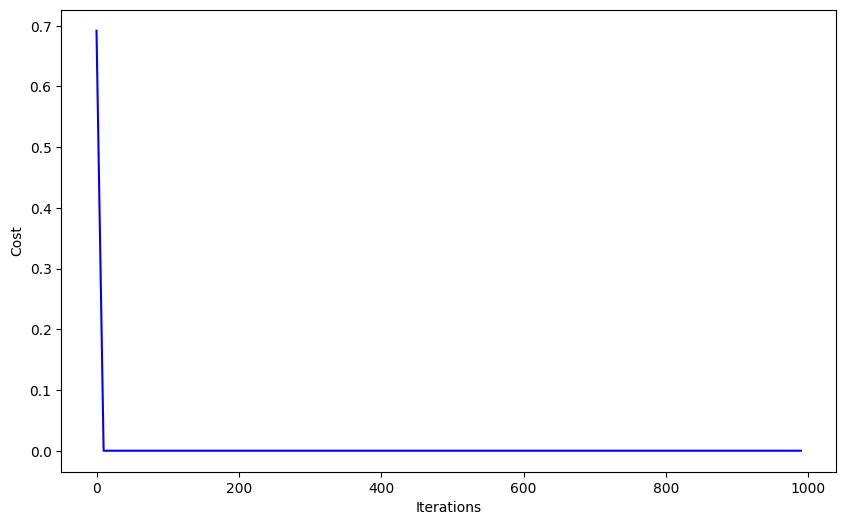

In [46]:
plt.figure(figsize=(10,6))
history = pd.DataFrame({
    "Iterations":range(0,len(model.J_history)*10,10),
    "Cost":model.J_history
})
sns.lineplot(data=history,x="Iterations",y="Cost",color="b")
plt.show()

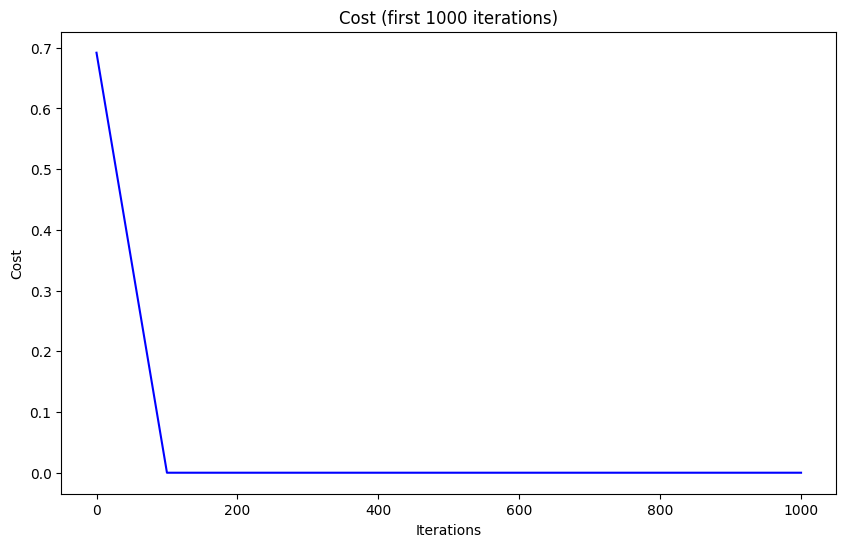

In [49]:
plt.figure(figsize=(10,6))
history = pd.DataFrame({
    "Iterations": range(0, len(model.J_history)*100, 100),
    "Cost": model.J_history
})
# Zoom into first 1000 iterations only
early = history[history["Iterations"] <= 1000]
sns.lineplot(data=early, x="Iterations", y="Cost", color="b")
plt.title("Cost (first 1000 iterations)")
plt.show()